# 02 — Construcción del Dataset obra_v4 con Feature Engineering

**Proyecto:** Sistema de Detección de Riesgos de Corrupción en Obras Públicas mediante ML  
**Tesis:** Maestría en Inteligencia Artificial – UNI  
**Autor:** Fernando García Atúncar  
**Versión:** v2.0 — Sprint 2 (mejorado post-EDA inicial)

---

## Cambios respecto a v1.0

| Bloque | Mejora |
|--------|--------|
| 3.2 Participantes | + `obra_n_contratos_postor_unico`, `obra_pct_postor_unico` |
| 3.3 Montos | + `obra_pct_montos_identicos`, `obra_ratio_ganador_media`, `obra_n_postores_igual_ganador` |
| 3.4 Ejecución | + `obra_n_alertas_total`, `obra_sobreavance`, `obra_desv_std_brecha` |
| 3.5 **NUEVO** | Features de contexto desde o1a: `SECTOR`, `NIVEL_GOBIERNO`, `OBJETO_PROCESO`, `METODO_CONTRATACION` |
| 3.6 **NUEVO** | Features contractuales desde o2a3a: ratios económicos del contrato ganador |
| 3.7 **NUEVO** | Features de estado desde o4a: `ESTADO_OBRA`, indicadores de ejecutora/supervisora |
| 4 Target | Bloque explícito de decisión de reducción de clases |
| 5 Merge | Merge incremental con log de cobertura por bloque |
| 6 Validación | Heatmap de nulos, reporte de cobertura y catálogo de features |
| 7 Export | Exporta versión full + versión sin NaN críticos |

---

## Unidad de análisis
```
1 fila = 1 IDENTIFICADOR_OBRA  (obra × proceso × contrato)
```

## TARGET
```
y_riesgo_obra → derivado de RIESGO_OBRA en o4b
```


---
## PASO 0 — Imports y configuración

In [91]:
# ============================================================
# IMPORTS
# ============================================================

from pathlib import Path
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.4f}".format)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100

print("✅ Imports OK")


✅ Imports OK


In [92]:
# ============================================================
# RUTAS
# ============================================================

BASE     = Path(r"C:\IA_Investigacion\Deteccion_Corrupcion")
DATA_EXT = BASE / "data" / "external" / "obra"
DATA_PROC = BASE / "data" / "processed"

DATA_PROC.mkdir(parents=True, exist_ok=True)

FILES_OBRA = {
    "o1a":   "DS_DASH_Obra_1A.csv",
    "o2a3a": "DS_DASH_Obra_2A_3A.csv",
    "o2b":   "DS_DASH_Obra_2B.csv",
    "o3b":   "DS_DASH_Obra_3B.csv",
    "o3c":   "DS_DASH_Obra_3C.csv",
    "o4a":   "DS_DASH_Obra_4A.csv",
    "o4b":   "DS_DASH_Obra_4B.csv",
    "o5a":   "DS_DASH_Obra_5A.csv",
}

print("BASE     :", BASE)
print("DATA_EXT :", DATA_EXT)
print("DATA_PROC:", DATA_PROC)


BASE     : C:\IA_Investigacion\Deteccion_Corrupcion
DATA_EXT : C:\IA_Investigacion\Deteccion_Corrupcion\data\external\obra
DATA_PROC: C:\IA_Investigacion\Deteccion_Corrupcion\data\processed


---
## PASO 1 — Carga de datasets

In [93]:
# ============================================================
# FUNCIONES UTILITARIAS
# ============================================================

def read_csv_robust(path: Path) -> pd.DataFrame:
    for enc in ["utf-8", "utf-8-sig", "latin1", "cp1252"]:
        try:
            df = pd.read_csv(path, encoding=enc)
            df.attrs["encoding"] = enc
            return df
        except Exception:
            continue
    raise ValueError(f"No se pudo leer: {path}")


def normalize_cols(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = (
        df.columns.astype(str)
        .str.strip()
        .str.replace("\ufeff", "", regex=False)
        .str.replace(" ", "_", regex=False)
        .str.upper()
    )
    return df


def normalize_key(s: pd.Series) -> pd.Series:
    """Normaliza llaves de unión: strip + upper."""
    return s.astype(str).str.strip().str.upper()


# ============================================================
# CARGA DESDE data/interim/ (datasets limpios)
# ============================================================

DATA_INTERIM = BASE / "data" / "interim"

ALIASES = ["o1a", "o2a3a", "o2b", "o3b", "o3c", "o4a", "o4b", "o5a"]

tablas_obra = {}

for alias in ALIASES:
    path = DATA_INTERIM / f"{alias}_clean.parquet"
    df = pd.read_parquet(path)
    tablas_obra[alias] = df
    print(f"✅ {alias:8s} | {df.shape[0]:>5,} × {df.shape[1]:>2} cols")


✅ o1a      |   326 × 12 cols
✅ o2a3a    |   552 × 22 cols
✅ o2b      | 1,613 ×  6 cols
✅ o3b      | 5,249 × 20 cols
✅ o3c      | 5,249 ×  8 cols
✅ o4a      |   326 ×  9 cols
✅ o4b      |   326 × 15 cols
✅ o5a      |   634 × 15 cols


---
## PASO 2 — Validación de llaves y relaciones

In [94]:
# ============================================================
# UNICIDAD DE LLAVES CANDIDATAS
# ============================================================

candidate_keys = ["CODIGO_UNICO", "IDENTIFICADOR_OBRA", "CODIGO_OBRA", "CODIGO_CONTRATO"]

rows = []
for alias, df in tablas_obra.items():
    for col in candidate_keys:
        if col not in df.columns:
            continue
        n = len(df)
        nu = df[col].nunique(dropna=True)
        rows.append({"dataset": alias, "llave": col, "filas": n,
                     "unicos": nu, "pct_unicidad": round(nu/n*100, 1)})

keys_df = pd.DataFrame(rows)
display(keys_df.sort_values(["dataset", "pct_unicidad"], ascending=[True, False]).reset_index(drop=True))


,dataset,llave,filas,unicos,pct_unicidad
0,o1a,IDENTIFICADOR_OBRA,326,326,100.0000
1,o1a,CODIGO_OBRA,326,232,71.2000
2,o1a,CODIGO_UNICO,326,170,52.1000
3,o2a3a,IDENTIFICADOR_OBRA,552,324,58.7000
4,o2a3a,CODIGO_CONTRATO,552,316,57.2000
5,o2a3a,CODIGO_OBRA,552,230,41.7000
6,o2a3a,CODIGO_UNICO,552,168,30.4000
7,o2b,IDENTIFICADOR_OBRA,1613,259,16.1000
8,o2b,CODIGO_UNICO,1613,125,7.7000
9,o3b,IDENTIFICADOR_OBRA,5249,324,6.2000


In [95]:
# ============================================================
# RELACIONES ENTRE LLAVES (cardinalidad)
# ============================================================

relation_pairs = [
    ("CODIGO_UNICO",       "IDENTIFICADOR_OBRA"),
    ("IDENTIFICADOR_OBRA", "CODIGO_OBRA"),
    ("IDENTIFICADOR_OBRA", "CODIGO_CONTRATO"),
]

for alias, df in tablas_obra.items():
    for left, right in relation_pairs:
        if left not in df.columns or right not in df.columns:
            continue
        rel = df.groupby(left)[right].nunique()
        multi = (rel > 1).mean() * 100
        print(f"{alias:8s} | {left} → {right:25s} | max={rel.max():>4} | media={rel.mean():.1f} | multi={multi:.1f}%")


o1a      | CODIGO_UNICO → IDENTIFICADOR_OBRA        | max=  17 | media=1.9 | multi=42.9%
o1a      | IDENTIFICADOR_OBRA → CODIGO_OBRA               | max=   1 | media=1.0 | multi=0.0%
o2a3a    | CODIGO_UNICO → IDENTIFICADOR_OBRA        | max=  17 | media=1.9 | multi=43.5%
o2a3a    | IDENTIFICADOR_OBRA → CODIGO_OBRA               | max=   1 | media=1.0 | multi=0.0%
o2a3a    | IDENTIFICADOR_OBRA → CODIGO_CONTRATO           | max=   1 | media=1.0 | multi=0.0%
o2b      | CODIGO_UNICO → IDENTIFICADOR_OBRA        | max=  17 | media=2.1 | multi=48.8%
o3b      | CODIGO_UNICO → IDENTIFICADOR_OBRA        | max=  17 | media=1.9 | multi=43.5%
o3b      | IDENTIFICADOR_OBRA → CODIGO_OBRA               | max=   1 | media=1.0 | multi=0.0%
o3b      | IDENTIFICADOR_OBRA → CODIGO_CONTRATO           | max=   1 | media=1.0 | multi=0.0%
o3c      | IDENTIFICADOR_OBRA → CODIGO_CONTRATO           | max=   1 | media=1.0 | multi=0.0%
o4b      | CODIGO_UNICO → IDENTIFICADOR_OBRA        | max=  17 | media=1.9 | mul

---
## PASO 3 — Feature Engineering

Cada bloque produce una tabla `feat_*` con clave `IDENTIFICADOR_OBRA`.

### 3.1 — Features de contexto (o1a) ✦ NUEVO

Variables categóricas que describen el tipo de obra y su entidad contratante.  
Señal de riesgo: ciertos sectores, métodos o niveles de gobierno correlacionan con mayor riesgo.


In [96]:
# ============================================================
# 3.1 — CONTEXTO DESDE o1a
# ============================================================

df_o1a = tablas_obra["o1a"].copy()

# Normalizar llave
df_o1a["IDENTIFICADOR_OBRA"] = normalize_key(df_o1a["IDENTIFICADOR_OBRA"])

# Columnas categóricas de contexto
COLS_CONTEXTO = [
    "IDENTIFICADOR_OBRA",
    "SECTOR",
    "NIVEL_GOBIERNO",
    "OBJETO_PROCESO",
    "METODO_CONTRATACION",
    "DEPARTAMENTO",
]

# Validar que existan
COLS_CONTEXTO = [c for c in COLS_CONTEXTO if c in df_o1a.columns]

feat_contexto = (
    df_o1a[COLS_CONTEXTO]
    .drop_duplicates(subset=["IDENTIFICADOR_OBRA"])
    .copy()
)

# Renombrar con prefijo obra_ctx_
rename_map = {c: f"obra_ctx_{c.lower()}" for c in COLS_CONTEXTO if c != "IDENTIFICADOR_OBRA"}
feat_contexto = feat_contexto.rename(columns=rename_map)

print(f"✅ feat_contexto: {feat_contexto.shape}")
display(feat_contexto.head())


✅ feat_contexto: (326, 6)


,IDENTIFICADOR_OBRA,obra_ctx_sector,obra_ctx_nivel_gobierno,obra_ctx_objeto_proceso,obra_ctx_metodo_contratacion,obra_ctx_departamento
0,2002060-2434-702592-2064311-19777,TRANSPORTE,GOBIERNO NACIONAL,Consultoría de Obra,Concurso Público,MULTIDEPARTAMENTAL
1,2002210-8880-869397-2169938-826,TRANSPORTE,GOBIERNO NACIONAL,Consultoría de Obra,Concurso Público,MULTIDEPARTAMENTAL
2,2002210-8880-870112-2169901-826,TRANSPORTE,GOBIERNO NACIONAL,Consultoría de Obra,Concurso Público,MULTIDEPARTAMENTAL
3,2015918-1249-721938-2074791-45660,TRANSPORTE,GOBIERNO NACIONAL,Consultoría de Obra,Concurso Público,MULTIDEPARTAMENTAL
4,2026767-16256-709096-2067605-143536,TRANSPORTE,GOBIERNO NACIONAL,Consultoría de Obra,Concurso Público,MULTIDEPARTAMENTAL


### 3.2 — Features contractuales (o2a3a) ✦ NUEVO

Ratios económicos del contrato ganador.  
Señal de riesgo: monto sobre referencial, dispersión entre oferta y contrato.


In [97]:
# ============================================================
# 3.2 — FEATURES CONTRACTUALES DESDE o2a3a
# ============================================================

df_o2a3a = tablas_obra["o2a3a"].copy()
df_o2a3a["IDENTIFICADOR_OBRA"] = normalize_key(df_o2a3a["IDENTIFICADOR_OBRA"])

# Detectar columna de participantes (nombre puede variar)
col_part = next(
    (c for c in df_o2a3a.columns if "PARTICIPANTE" in c and "TOTAL" in c), None
)

agg_dict = {
    "obra_monto_contractual_sum":   ("MONTO_CONTRACTUAL",    "sum"),
    "obra_monto_referencial_sum":   ("MONTO_REFERENCIAL",    "sum"),
    "obra_monto_ofertado_prom_mean":("MONTO_OFERTADO_PROMEDIO", "mean"),
    "obra_n_contratos_ganados":     ("CODIGO_CONTRATO",      "nunique"),
}

if col_part:
    agg_dict["obra_n_participantes_mean"] = (col_part, "mean")
    agg_dict["obra_n_participantes_max"]  = (col_part, "max")

feat_contractual = (
    df_o2a3a
    .groupby("IDENTIFICADOR_OBRA")
    .agg(**agg_dict)
    .reset_index()
)

# Ratios derivados
feat_contractual["obra_ratio_contractual_referencial"] = (
    feat_contractual["obra_monto_contractual_sum"]
    / feat_contractual["obra_monto_referencial_sum"]
).replace([np.inf, -np.inf], np.nan)

feat_contractual["obra_ahorro_absoluto"] = (
    feat_contractual["obra_monto_referencial_sum"]
    - feat_contractual["obra_monto_contractual_sum"]
)

feat_contractual["obra_sobre_referencial"] = (
    feat_contractual["obra_ratio_contractual_referencial"] > 1
).astype(int)

feat_contractual["obra_ratio_oferta_contrato"] = (
    feat_contractual["obra_monto_ofertado_prom_mean"]
    / feat_contractual["obra_monto_contractual_sum"]
).replace([np.inf, -np.inf], np.nan)

print(f"✅ feat_contractual: {feat_contractual.shape}")
display(feat_contractual.head())
print("\nEstadísticas clave:")
display(feat_contractual[["obra_ratio_contractual_referencial", "obra_sobre_referencial"]].describe())


✅ feat_contractual: (324, 11)


,IDENTIFICADOR_OBRA,obra_monto_contractual_sum,obra_monto_referencial_sum,obra_monto_ofertado_prom_mean,obra_n_contratos_ganados,obra_n_participantes_mean,obra_n_participantes_max,obra_ratio_contractual_referencial,obra_ahorro_absoluto,obra_sobre_referencial,obra_ratio_oferta_contrato
0,2002060-2434-702592-2064311-19777,"2,235,852.5600","2,484,280.6200","2,276,555.1800",1,81.0000,81,0.9000,"248,428.0600",0,1.0182
1,2002210-8880-869397-2169938-826,"331,016.9900","367,796.6500","331,168.2200",1,123.0000,123,0.9000,"36,779.6600",0,1.0005
2,2002210-8880-870112-2169901-826,"283,575.2300","315,083.5800","284,563.6600",1,181.0000,181,0.9000,"31,508.3500",0,1.0035
3,2026767-16256-709096-2067605-143536,"4,954,715.5400","5,505,239.4800","2,477,357.7700",1,44.5000,69,0.9000,"550,523.9400",0,0.5000
4,2027711-3876-682536-2050524-138320,"3,043,955.2500","3,382,172.4900","3,073,365.4400",1,144.0000,144,0.9000,"338,217.2400",0,1.0097



Estadísticas clave:


,obra_ratio_contractual_referencial,obra_sobre_referencial
count,324.0000,324.0000
mean,0.9134,0.0679
std,0.1865,0.2520
min,0.0515,0.0000
25%,0.9000,0.0000
50%,0.9000,0.0000
75%,1.0000,0.0000
max,1.8922,1.0000


### 3.3 — Features de comité (o2b)

Densidad y repetición de evaluadores.  
Señal de riesgo: evaluadores recurrentes → posible captura del evaluador.


In [98]:
# ============================================================
# 3.3 — FEATURES COMITÉ DESDE o2b
# ============================================================

df_o2b = tablas_obra["o2b"].copy()
df_o2b["IDENTIFICADOR_OBRA"]  = normalize_key(df_o2b["IDENTIFICADOR_OBRA"])
df_o2b["DNI_MIEMBRO_COMITE"]  = normalize_key(df_o2b["DNI_MIEMBRO_COMITE"])

feat_comite = (
    df_o2b
    .groupby("IDENTIFICADOR_OBRA")
    .agg(
        obra_n_miembros_comite       =("DNI_MIEMBRO_COMITE", "count"),
        obra_n_dnis_comite_unicos    =("DNI_MIEMBRO_COMITE", "nunique"),
        obra_n_convocatorias_comite  =("CONVOCATORIA",       "nunique"),
        obra_n_procesos_comite       =("PROCESO",            "nunique"),
    )
    .reset_index()
)

feat_comite["obra_ratio_repeticion_comite"] = (
    feat_comite["obra_n_miembros_comite"]
    / feat_comite["obra_n_dnis_comite_unicos"]
).replace([np.inf, -np.inf], np.nan)

feat_comite["obra_comite_no_estandar"] = (
    feat_comite["obra_n_dnis_comite_unicos"] != 6
).astype(int)

print(f"✅ feat_comite: {feat_comite.shape}")
display(feat_comite.head())

✅ feat_comite: (259, 7)


,IDENTIFICADOR_OBRA,obra_n_miembros_comite,obra_n_dnis_comite_unicos,obra_n_convocatorias_comite,obra_n_procesos_comite,obra_ratio_repeticion_comite,obra_comite_no_estandar
0,2002060-2434-702592-2064311-19777,6,6,1,1,1.0000,0
1,2002210-8880-869397-2169938-826,6,6,1,1,1.0000,0
2,2002210-8880-870112-2169901-826,6,6,1,1,1.0000,0
3,2015918-1249-721938-2074791-45660,6,6,1,1,1.0000,0
4,2026767-16256-709096-2067605-143536,6,6,1,1,1.0000,0


### 3.4 — Features de participantes (o3b)

Nivel de competencia real en el proceso.  
Señal de riesgo: postor único, alta concentración → direccionamiento.


In [99]:
# ============================================================
# 3.4 — FEATURES PARTICIPANTES DESDE o3b
# ============================================================

df_o3b = tablas_obra["o3b"].copy()
df_o3b["IDENTIFICADOR_OBRA"]      = normalize_key(df_o3b["IDENTIFICADOR_OBRA"])
df_o3b["CODIGO_RUC_PARTICIPANTE"] = normalize_key(df_o3b["CODIGO_RUC_PARTICIPANTE"])
df_o3b["CODIGO_CONTRATO"]         = normalize_key(df_o3b["CODIGO_CONTRATO"])

# ── Base de agregación ────────────────────────────────────────
feat_participantes = (
    df_o3b
    .groupby("IDENTIFICADOR_OBRA")
    .agg(
        obra_n_participaciones         =("CODIGO_RUC_PARTICIPANTE", "count"),
        obra_n_rucs_participantes      =("CODIGO_RUC_PARTICIPANTE", "nunique"),
        obra_n_contratos               =("CODIGO_CONTRATO",         "nunique"),
        obra_n_procesos                =("PROCESO",                 "nunique"),
    )
    .reset_index()
)

# ── Contratos con postor único ✦ NUEVO ──────────────────────
postores_x_contrato = (
    df_o3b
    .groupby(["IDENTIFICADOR_OBRA", "CODIGO_CONTRATO"])["CODIGO_RUC_PARTICIPANTE"]
    .nunique()
    .reset_index(name="n_postores")
)

postor_unico = (
    postores_x_contrato
    .groupby("IDENTIFICADOR_OBRA")
    .agg(
        obra_n_contratos_postor_unico=("n_postores", lambda x: (x == 1).sum()),
        obra_n_contratos_total_part  =("n_postores", "count"),
        obra_n_postores_mean         =("n_postores", "mean"),
        obra_n_postores_min          =("n_postores", "min"),
        obra_n_postores_max          =("n_postores", "max"),
    )
    .reset_index()
)

postor_unico["obra_pct_postor_unico"] = (
    postor_unico["obra_n_contratos_postor_unico"]
    / postor_unico["obra_n_contratos_total_part"]
).fillna(0)

feat_participantes = feat_participantes.merge(postor_unico, on="IDENTIFICADOR_OBRA", how="left")

# ── Ratios de densidad ────────────────────────────────────────
feat_participantes["obra_ratio_participacion"] = (
    feat_participantes["obra_n_participaciones"]
    / feat_participantes["obra_n_rucs_participantes"]
).replace([np.inf, -np.inf], np.nan)

feat_participantes["obra_ratio_contrato_participacion"] = (
    feat_participantes["obra_n_contratos"]
    / feat_participantes["obra_n_participaciones"]
).replace([np.inf, -np.inf], np.nan)

print(f"✅ feat_participantes: {feat_participantes.shape}")
display(feat_participantes.head())

print("\nContratos con postor único:")
print(feat_participantes[["obra_n_contratos_postor_unico", "obra_pct_postor_unico"]].describe())


✅ feat_participantes: (324, 13)


,IDENTIFICADOR_OBRA,obra_n_participaciones,obra_n_rucs_participantes,obra_n_contratos,obra_n_procesos,obra_n_contratos_postor_unico,obra_n_contratos_total_part,obra_n_postores_mean,obra_n_postores_min,obra_n_postores_max,obra_pct_postor_unico,obra_ratio_participacion,obra_ratio_contrato_participacion
0,2002060-2434-702592-2064311-19777,6,6,1,1,0,1,6.0000,6,6,0.0000,1.0000,0.1667
1,2002210-8880-869397-2169938-826,14,14,1,1,0,1,14.0000,14,14,0.0000,1.0000,0.0714
2,2002210-8880-870112-2169901-826,13,13,1,1,0,1,13.0000,13,13,0.0000,1.0000,0.0769
3,2026767-16256-709096-2067605-143536,20,10,1,1,0,1,10.0000,10,10,0.0000,2.0000,0.0500
4,2027711-3876-682536-2050524-138320,23,23,1,1,0,1,23.0000,23,23,0.0000,1.0000,0.0435



Contratos con postor único:
       obra_n_contratos_postor_unico  obra_pct_postor_unico
count                       324.0000               324.0000
mean                          0.2222                 0.2222
std                           0.4164                 0.4164
min                           0.0000                 0.0000
25%                           0.0000                 0.0000
50%                           0.0000                 0.0000
75%                           0.0000                 0.0000
max                           1.0000                 1.0000


### 3.5 — Features monetarias (o3c)

Dispersión y patrones de ofertas. Las señales más fuertes de colusión están aquí.  
Señal de riesgo: `obra_cv_ofertas` bajo, `obra_pct_montos_identicos` alto → concertación.


In [100]:
# ============================================================
# 3.5 — FEATURES MONETARIAS DESDE o3c
# ============================================================

df_o3c = tablas_obra["o3c"].copy()
df_o3c["IDENTIFICADOR_OBRA"] = normalize_key(df_o3c["IDENTIFICADOR_OBRA"])
df_o3c["CODIGO_CONTRATO"]    = normalize_key(df_o3c["CODIGO_CONTRATO"])
df_o3c["RUC_GANADOR"]        = normalize_key(df_o3c["RUC_GANADOR"])
df_o3c["RUC_PARTICIPANTE"]   = normalize_key(df_o3c["RUC_PARTICIPANTE"])
df_o3c["MONTO_OFERTADO"]     = pd.to_numeric(df_o3c["MONTO_OFERTADO"], errors="coerce")

# ── Agregación base por obra ──────────────────────────────────
feat_montos = (
    df_o3c
    .groupby("IDENTIFICADOR_OBRA")
    .agg(
        obra_monto_ofertado_mean =("MONTO_OFERTADO", "mean"),
        obra_monto_ofertado_std  =("MONTO_OFERTADO", "std"),
        obra_monto_ofertado_min  =("MONTO_OFERTADO", "min"),
        obra_monto_ofertado_max  =("MONTO_OFERTADO", "max"),
        obra_n_ofertas           =("MONTO_OFERTADO", "count"),
    )
    .reset_index()
)

# ── CV y rango ────────────────────────────────────────────────
feat_montos["obra_rango_ofertas"] = (
    feat_montos["obra_monto_ofertado_max"] - feat_montos["obra_monto_ofertado_min"]
)

feat_montos["obra_cv_ofertas"] = (
    feat_montos["obra_monto_ofertado_std"] / feat_montos["obra_monto_ofertado_mean"]
).replace([np.inf, -np.inf], np.nan)

# ── % contratos con montos idénticos ✦ NUEVO ─────────────────
montos_unicos_x_contrato = (
    df_o3c
    .groupby(["IDENTIFICADOR_OBRA", "CODIGO_CONTRATO"])["MONTO_OFERTADO"]
    .nunique()
    .reset_index(name="n_montos_unicos")
)

identicos_agg = (
    montos_unicos_x_contrato
    .groupby("IDENTIFICADOR_OBRA")
    .agg(
        obra_n_contratos_montos_identicos=("n_montos_unicos", lambda x: (x == 1).sum()),
        obra_n_contratos_con_montos      =("n_montos_unicos", "count"),
    )
    .reset_index()
)

identicos_agg["obra_pct_montos_identicos"] = (
    identicos_agg["obra_n_contratos_montos_identicos"]
    / identicos_agg["obra_n_contratos_con_montos"]
).fillna(0)

feat_montos = feat_montos.merge(identicos_agg, on="IDENTIFICADOR_OBRA", how="left")

# ── Ratio oferta ganador vs media total ✦ NUEVO ──────────────
df_o3c["es_ganador"] = df_o3c["RUC_GANADOR"] == df_o3c["RUC_PARTICIPANTE"]

ganador_monto = (
    df_o3c[df_o3c["es_ganador"]]
    .groupby("IDENTIFICADOR_OBRA")["MONTO_OFERTADO"]
    .mean()
    .reset_index(name="obra_monto_ganador_mean")
)

feat_montos = feat_montos.merge(ganador_monto, on="IDENTIFICADOR_OBRA", how="left")

feat_montos["obra_ratio_ganador_media"] = (
    feat_montos["obra_monto_ganador_mean"]
    / feat_montos["obra_monto_ofertado_mean"]
).replace([np.inf, -np.inf], np.nan)

# ── N° postores que ofertaron IGUAL al ganador ✦ NUEVO ───────
df_ganadores = df_o3c[df_o3c["es_ganador"]][["CODIGO_CONTRATO", "MONTO_OFERTADO"]].rename(
    columns={"MONTO_OFERTADO": "monto_ganador"}
)
df_comp = df_o3c.merge(df_ganadores, on="CODIGO_CONTRATO", how="left")
df_comp["igual_ganador"] = (
    (~df_comp["es_ganador"]) & (df_comp["MONTO_OFERTADO"] == df_comp["monto_ganador"])
).astype(int)

igual_ganador_agg = (
    df_comp.groupby("IDENTIFICADOR_OBRA")["igual_ganador"]
    .sum()
    .reset_index(name="obra_n_postores_igual_ganador")
)

feat_montos = feat_montos.merge(igual_ganador_agg, on="IDENTIFICADOR_OBRA", how="left")

feat_montos["obra_pct_postores_igual_ganador"] = (
    feat_montos["obra_n_postores_igual_ganador"]
    / feat_montos["obra_n_ofertas"]
).fillna(0)

print(f"✅ feat_montos: {feat_montos.shape}")
display(feat_montos.head())
print("\nSeñales de colusión (resumen):")
print(feat_montos[["obra_cv_ofertas", "obra_pct_montos_identicos", "obra_pct_postores_igual_ganador"]].describe())


✅ feat_montos: (324, 15)


,IDENTIFICADOR_OBRA,obra_monto_ofertado_mean,obra_monto_ofertado_std,obra_monto_ofertado_min,obra_monto_ofertado_max,obra_n_ofertas,obra_rango_ofertas,obra_cv_ofertas,obra_n_contratos_montos_identicos,obra_n_contratos_con_montos,obra_pct_montos_identicos,obra_monto_ganador_mean,obra_ratio_ganador_media,obra_n_postores_igual_ganador,obra_pct_postores_igual_ganador
0,2002060-2434-702592-2064311-19777,"2,276,555.1817","99,700.6543","2,235,852.5600","2,480,068.2900",6,"244,215.7300",0.0438,0,1,0.0000,"2,235,852.5600",0.9821,4,0.6667
1,2002210-8880-869397-2169938-826,"307,513.3493","88,509.1410",0.0000,"332,000.0000",14,"332,000.0000",0.2878,0,1,0.0000,"331,016.9900",1.0764,10,0.7143
2,2002210-8880-870112-2169901-826,"284,563.6562","2,412.7183","283,575.2300","290,000.0000",13,"6,424.7700",0.0085,0,1,0.0000,"283,575.2300",0.9965,10,0.7692
3,2026767-16256-709096-2067605-143536,"2,477,357.7700",0.0000,"2,477,357.7700","2,477,357.7700",20,0.0000,0.0000,1,1,1.0000,"2,477,357.7700",1.0000,36,1.8000
4,2027711-3876-682536-2050524-138320,"3,073,365.4448","97,441.7619","3,043,955.2500","3,382,172.4900",23,"338,217.2400",0.0317,0,1,0.0000,"3,043,955.2500",0.9904,20,0.8696



Señales de colusión (resumen):
       obra_cv_ofertas  obra_pct_montos_identicos  \
count         252.0000                   324.0000   
mean            0.1055                     0.6049   
std             0.3388                     0.4896   
min             0.0000                     0.0000   
25%             0.0000                     0.0000   
50%             0.0000                     1.0000   
75%             0.0499                     1.0000   
max             2.4410                     1.0000   

       obra_pct_postores_igual_ganador  
count                         324.0000  
mean                            0.8330  
std                             0.8352  
min                             0.0000  
25%                             0.0000  
50%                             0.7500  
75%                             1.1456  
max                             6.3824  


In [101]:
# Imputación dirigida — contratos con postor único (std indefinido)
feat_montos['obra_monto_ofertado_std'] = feat_montos['obra_monto_ofertado_std'].fillna(0)
feat_montos['obra_cv_ofertas']         = feat_montos['obra_cv_ofertas'].fillna(0)

### 3.6 — Features de ejecución física (o5a)

Desempeño real vs planificado e indicadores de alerta.  
Señal de riesgo: retraso sostenido, sin ejecución, alertas de adelanto → riesgo operativo/financiero.


In [102]:
# ============================================================
# 3.6 — FEATURES EJECUCIÓN DESDE o5a
# ============================================================

df_o5a = tablas_obra["o5a"].copy()
df_o5a["IDENTIFICADOR_OBRA"] = normalize_key(df_o5a["IDENTIFICADOR_OBRA"])
df_o5a["PLANIFICADO"] = pd.to_numeric(df_o5a["PLANIFICADO"], errors="coerce")
df_o5a["REAL"]        = pd.to_numeric(df_o5a["REAL"],        errors="coerce")
df_o5a["brecha"]      = df_o5a["REAL"] - df_o5a["PLANIFICADO"]

# ── Agregación base ───────────────────────────────────────────
feat_ejecucion = (
    df_o5a
    .groupby("IDENTIFICADOR_OBRA")
    .agg(
        obra_planificado_mean   =("PLANIFICADO", "mean"),
        obra_real_mean          =("REAL",        "mean"),
        obra_planificado_max    =("PLANIFICADO", "max"),
        obra_real_max           =("REAL",        "max"),
        obra_brecha_mean        =("brecha",      "mean"),
        obra_brecha_min         =("brecha",      "min"),
        obra_brecha_std         =("brecha",      "std"),   # ✦ NUEVO
        obra_n_registros_ejec   =("REAL",        "count"),
        obra_n_anhos            =("ANHO",        "nunique"),
        obra_n_meses            =("MES",         "nunique"),
    )
    .reset_index()
)

# ── Ratios derivados ──────────────────────────────────────────

feat_ejecucion["obra_desviacion_real_plan"] = feat_ejecucion["obra_brecha_mean"]


# ── Imputación dirigida D2 ────────────────────────────────────
feat_ejecucion["obra_ratio_real_plan"] = np.where(
    feat_ejecucion["obra_planificado_mean"] == 0,
    0.0,
    feat_ejecucion["obra_real_mean"] / feat_ejecucion["obra_planificado_mean"]
)
feat_ejecucion["obra_brecha_std"] = feat_ejecucion["obra_brecha_std"].fillna(0)

# ── Flags binarios ────────────────────────────────────────────
feat_ejecucion["obra_planificado_cero"] = (feat_ejecucion["obra_planificado_mean"] == 0).astype(int)
feat_ejecucion["obra_real_cero"]        = (feat_ejecucion["obra_real_mean"]        == 0).astype(int)

feat_ejecucion["obra_sin_ejecucion"] = (
    (feat_ejecucion["obra_planificado_mean"] == 0) &
    (feat_ejecucion["obra_real_mean"]        == 0)
).astype(int)

feat_ejecucion["obra_sobreavance"] = (          # ✦ NUEVO: real > plan (anomalía o mala prog.)
    feat_ejecucion["obra_real_max"] > feat_ejecucion["obra_planificado_max"]
).astype(int)

# ── Alertas por indicador ✦ NUEVO ────────────────────────────
cols_ind = [c for c in df_o5a.columns if c.startswith("IND_")]

if cols_ind:
    alerta_df = df_o5a.copy()
    for c in cols_ind:
        alerta_df[c + "_flag"] = (alerta_df[c] == "ALERTA").astype(int)

    flag_cols = [c + "_flag" for c in cols_ind]
    alerta_df["n_alertas_fila"] = alerta_df[flag_cols].sum(axis=1)

    alertas_agg = (
        alerta_df
        .groupby("IDENTIFICADOR_OBRA")["n_alertas_fila"]
        .agg(
            obra_n_alertas_total ="sum",
            obra_n_filas_con_alerta=lambda x: (x > 0).sum(),
        )
        .reset_index()
    )

    feat_ejecucion = feat_ejecucion.merge(alertas_agg, on="IDENTIFICADOR_OBRA", how="left")
    feat_ejecucion["obra_n_alertas_total"]      = feat_ejecucion["obra_n_alertas_total"].fillna(0)
    feat_ejecucion["obra_n_filas_con_alerta"]   = feat_ejecucion["obra_n_filas_con_alerta"].fillna(0)

    feat_ejecucion["obra_pct_filas_con_alerta"] = (
        feat_ejecucion["obra_n_filas_con_alerta"] / feat_ejecucion["obra_n_registros_ejec"]
    ).fillna(0)

print(f"✅ feat_ejecucion: {feat_ejecucion.shape}")
display(feat_ejecucion.head())


✅ feat_ejecucion: (326, 20)


,IDENTIFICADOR_OBRA,obra_planificado_mean,obra_real_mean,obra_planificado_max,obra_real_max,obra_brecha_mean,obra_brecha_min,obra_brecha_std,obra_n_registros_ejec,obra_n_anhos,obra_n_meses,obra_desviacion_real_plan,obra_ratio_real_plan,obra_planificado_cero,obra_real_cero,obra_sin_ejecucion,obra_sobreavance,obra_n_alertas_total,obra_n_filas_con_alerta,obra_pct_filas_con_alerta
0,2002060-2434-702592-2064311-19777,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1,0,0,0.0000,0.0000,1,1,1,0,0,0,0.0000
1,2002210-8880-869397-2169938-826,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1,0,0,0.0000,0.0000,1,1,1,0,0,0,0.0000
2,2002210-8880-870112-2169901-826,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1,0,0,0.0000,0.0000,1,1,1,0,0,0,0.0000
3,2015918-1249-721938-2074791-45660,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1,0,0,0.0000,0.0000,1,1,1,0,1,1,1.0000
4,2026767-16256-709096-2067605-143536,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1,0,0,0.0000,0.0000,1,1,1,0,0,0,0.0000


In [103]:
print(f"obras en feat_ejecucion : {len(feat_ejecucion)}")
print(f"NaN en ratio            : {feat_ejecucion['obra_ratio_real_plan'].isna().sum()}")
print(f"NaN en brecha_std       : {feat_ejecucion['obra_brecha_std'].isna().sum()}")

obras en feat_ejecucion : 326
NaN en ratio            : 0
NaN en brecha_std       : 0


### 3.7 — Features de estado de obra (o4a) ✦ NUEVO

Estado operativo y presencia de empresas asignadas.  
Señal de riesgo: obras paralizadas, sin ejecutora o sin supervisora.


In [104]:
# ============================================================
# 3.7 — FEATURES ESTADO DESDE o4a
# ============================================================

df_o4a = tablas_obra["o4a"].copy()
df_o4a["CODIGO_UNICO"] = normalize_key(df_o4a["CODIGO_UNICO"].astype(str))

# Crosswalk: CODIGO_UNICO → IDENTIFICADOR_OBRA (desde o4b)
xwalk = (
    tablas_obra["o4b"][["CODIGO_UNICO", "IDENTIFICADOR_OBRA"]]
    .copy()
)
xwalk["CODIGO_UNICO"]       = normalize_key(xwalk["CODIGO_UNICO"].astype(str))
xwalk["IDENTIFICADOR_OBRA"] = normalize_key(xwalk["IDENTIFICADOR_OBRA"])
xwalk = xwalk.drop_duplicates()

# Merge PRIMERO — antes de crear cualquier indicador
df_o4a = df_o4a.merge(xwalk, on="CODIGO_UNICO", how="left")

assert "IDENTIFICADOR_OBRA" in df_o4a.columns, "❌ Crosswalk falló"
assert df_o4a["IDENTIFICADOR_OBRA"].notna().mean() == 1.0, "❌ Cobertura incompleta"

# Indicadores binarios
df_o4a["tiene_ejecutora"]   = df_o4a["EMPRESA_EJECUTORA"].notna().astype(int)
df_o4a["tiene_supervisora"] = df_o4a["EMPRESA_SUPERVISORA"].notna().astype(int)
df_o4a["paralizada"]        = (df_o4a["ESTADO_OBRA"] == "Paralizada").astype(int)
df_o4a["inactiva"]          = (df_o4a["ESTADO_OBRA"] == "Inactivo").astype(int)
df_o4a["en_ejecucion"]      = (df_o4a["ESTADO_OBRA"] == "En Ejecución").astype(int)
df_o4a["finalizada"]        = (df_o4a["ESTADO_OBRA"] == "Finalizado").astype(int)

# Colapsar a 1 fila por IDENTIFICADOR_OBRA
feat_estado = (
    df_o4a
    .groupby("IDENTIFICADOR_OBRA")
    .agg(
        obra_tiene_ejecutora   =("tiene_ejecutora",   "max"),
        obra_tiene_supervisora =("tiene_supervisora", "max"),
        obra_paralizada        =("paralizada",         "max"),
        obra_inactiva          =("inactiva",           "max"),
        obra_en_ejecucion      =("en_ejecucion",       "max"),
        obra_finalizada        =("finalizada",         "max"),
    )
    .reset_index()
)

assert len(feat_estado) == 326, f"❌ feat_estado tiene {len(feat_estado)} filas, esperaba 326"
print(f"✅ feat_estado: {feat_estado.shape}")

✅ feat_estado: (326, 7)


---
## PASO 4 — Definición del TARGET

El target proviene de `RIESGO_OBRA` en o4b (valores 1–4).  
Aquí se toma la **decisión de reducción de clases**.


In [105]:
# ============================================================
# TARGET BASE
# ============================================================

df_o4b = tablas_obra["o4b"].copy()
df_o4b["IDENTIFICADOR_OBRA"] = normalize_key(df_o4b["IDENTIFICADOR_OBRA"])

base_obra = (
    df_o4b[["IDENTIFICADOR_OBRA", "RIESGO_OBRA", "RIESGO_DESCRIPCION_OBRA",
             "ETAPA", "DIAS_PLAZO",
             "TOTAL_CONTROL_PREVIO", "TOTAL_CONTROL_SIMULTANEO", "TOTAL_CONTROL_POSTERIOR"]]
    .drop_duplicates(subset=["IDENTIFICADOR_OBRA"])
    .copy()
)

print("Shape base_obra (target + contexto 4b):", base_obra.shape)

print("\nDistribución TARGET original:")
dist = base_obra.groupby(["RIESGO_OBRA", "RIESGO_DESCRIPCION_OBRA"]).size().reset_index(name="n")
dist["pct"] = (dist["n"] / dist["n"].sum() * 100).round(1)
display(dist)


Shape base_obra (target + contexto 4b): (326, 8)

Distribución TARGET original:


,RIESGO_OBRA,RIESGO_DESCRIPCION_OBRA,n,pct
0,0,Sin Riesgo,32,9.8000
1,1,Bajamente Riesgosa,52,16.0000
2,2,Medianamente Riesgosa,87,26.7000
3,3,Altamente Riesgosa,7,2.1000
4,4,Extremadamente Riesgosa,148,45.4000


In [106]:
# ============================================================
# TARGET FINAL — Decisión D1: 4 niveles
# Fusión:       clase 3 → clase 2  (semántica)
# Renumeración: clase 4 → clase 3  (clases contiguas para sklearn)
# ============================================================

MAPEO_4NIVELES = {0: 0, 1: 1, 2: 2, 3: 2, 4: 4}
RENUMERACION   = {0: 0, 1: 1, 2: 2, 4: 3}

ETIQUETAS = {
    0: "Sin Riesgo",
    1: "Bajamente Riesgosa",
    2: "Med/Alt Riesgosa (2+3)",
    3: "Extremadamente Riesgosa",
}

base_obra["y_riesgo_obra"] = (
    base_obra["RIESGO_OBRA"]
    .map(MAPEO_4NIVELES)
    .map(RENUMERACION)
)

# Validaciones
assert list(sorted(base_obra["y_riesgo_obra"].unique())) == [0, 1, 2, 3], \
    "❌ Clases no contiguas — revisar mapeo"

vc = base_obra["y_riesgo_obra"].value_counts().sort_index()

print("TARGET: y_riesgo_obra (4 niveles)")
print("=" * 50)
for cls, cnt in vc.items():
    pct = cnt / len(base_obra) * 100
    bar = "█" * int(pct / 2)
    print(f"  Clase {cls} — {ETIQUETAS[cls]:28s}: {cnt:>3} ({pct:4.1f}%) {bar}")

print(f"\n  Imbalance ratio : {vc.max()/vc.min():.2f}x")
print(f"  ✅ Clases contiguas {sorted(base_obra['y_riesgo_obra'].unique())}")

TARGET: y_riesgo_obra (4 niveles)
  Clase 0 — Sin Riesgo                  :  32 ( 9.8%) ████
  Clase 1 — Bajamente Riesgosa          :  52 (16.0%) ███████
  Clase 2 — Med/Alt Riesgosa (2+3)      :  94 (28.8%) ██████████████
  Clase 3 — Extremadamente Riesgosa     : 148 (45.4%) ██████████████████████

  Imbalance ratio : 4.62x
  ✅ Clases contiguas [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


---
## PASO 5 — Merge incremental

Cada bloque se une con `left join` preservando todas las obras del target.  
Se registra la cobertura (% de obras con dato) después de cada unión.


In [107]:
# ============================================================
# FUNCIÓN DE MERGE CON LOG
# ============================================================

def merge_with_log(base: pd.DataFrame, feat: pd.DataFrame,
                   key: str, label: str) -> pd.DataFrame:
    n_before = len(base)
    result = base.merge(feat, on=key, how="left")
    nuevas_cols = [c for c in feat.columns if c != key]
    cobertura = result[nuevas_cols].notna().mean().mean() * 100
    print(f"  + {label:35s} | cols: {len(nuevas_cols):>2} | cobertura: {cobertura:.1f}%")
    return result


# ============================================================
# MERGE PASO A PASO
# ============================================================

KEY = "IDENTIFICADOR_OBRA"

print(f"Base inicial: {base_obra.shape}")
print()

dataset = base_obra.copy()

dataset = merge_with_log(dataset, feat_contexto,      KEY, "feat_contexto (o1a)")
dataset = merge_with_log(dataset, feat_contractual,   KEY, "feat_contractual (o2a3a)")
dataset = merge_with_log(dataset, feat_comite,        KEY, "feat_comite (o2b)")
dataset = merge_with_log(dataset, feat_participantes, KEY, "feat_participantes (o3b)")
dataset = merge_with_log(dataset, feat_montos,        KEY, "feat_montos (o3c)")
dataset = merge_with_log(dataset, feat_ejecucion,     KEY, "feat_ejecucion (o5a)")
dataset = merge_with_log(dataset, feat_estado,        KEY, "feat_estado (o4a)")

# ── Imputación post-merge ─────────────────────────────────────
# Las obras sin registro en o2b (67 obras, 20.6%) generan NaN
# tras el left join. Imputar con 0 es semánticamente correcto:
# ausencia de comité documentado = 0 miembros, 0 convocatorias.
cols_comite = [
    "obra_n_miembros_comite",
    "obra_n_dnis_comite_unicos",
    "obra_n_convocatorias_comite",
    "obra_n_procesos_comite",
    "obra_ratio_repeticion_comite",
    "obra_comite_no_estandar",
]
for col in cols_comite:
    if col in dataset.columns:
        dataset[col] = dataset[col].fillna(0)

print(f"\nShape final: {dataset.shape}")
print(f"NaN totales tras imputación: {dataset.isna().sum().sum()}")


Base inicial: (326, 9)

  + feat_contexto (o1a)                 | cols:  5 | cobertura: 100.0%
  + feat_contractual (o2a3a)            | cols: 10 | cobertura: 99.4%
  + feat_comite (o2b)                   | cols:  6 | cobertura: 79.4%
  + feat_participantes (o3b)            | cols: 12 | cobertura: 99.4%
  + feat_montos (o3c)                   | cols: 14 | cobertura: 99.4%
  + feat_ejecucion (o5a)                | cols: 19 | cobertura: 100.0%
  + feat_estado (o4a)                   | cols:  6 | cobertura: 100.0%

Shape final: (326, 81)
NaN totales tras imputación: 72


---
## PASO 6 — Validación del dataset

In [108]:
# ============================================================
# 6.1 — DUPLICADOS
# ============================================================

dup = dataset.groupby(KEY).size()
dup_multi = (dup > 1).sum()
print(f"Obras con más de 1 fila: {dup_multi}  ← debe ser 0")

if dup_multi > 0:
    display(dup[dup > 1].head())


Obras con más de 1 fila: 0  ← debe ser 0


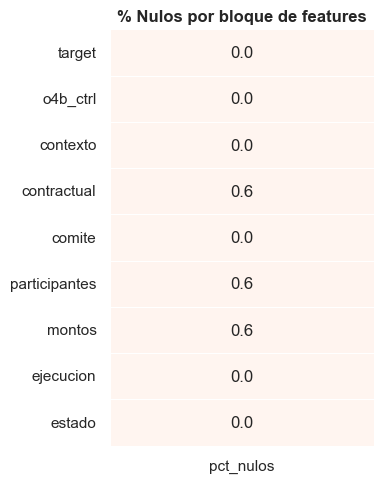

In [109]:
# ============================================================
# 6.2 — HEATMAP DE NULOS POR BLOQUE
# ============================================================

# Agrupar columnas por bloque
bloques = {
    "target":       ["y_riesgo_obra", "RIESGO_OBRA"],
    "o4b_ctrl":     ["ETAPA", "DIAS_PLAZO", "TOTAL_CONTROL_PREVIO",
                     "TOTAL_CONTROL_SIMULTANEO", "TOTAL_CONTROL_POSTERIOR"],
    "contexto":     [c for c in dataset.columns if c.startswith("obra_ctx_")],
    "contractual":  [c for c in dataset.columns if c.startswith("obra_monto_contractual")
                     or c.startswith("obra_monto_referencial") or "ratio_contractual" in c
                     or "sobre_referencial" in c or "ahorro" in c],
    "comite":       [c for c in dataset.columns if "comite" in c],
    "participantes":[c for c in dataset.columns if "participante" in c or "postor_unico" in c or "postores" in c],
    "montos":       [c for c in dataset.columns if "ofertado" in c or "cv_ofertas" in c
                     or "rango_ofertas" in c or "identicos" in c or "ganador" in c],
    "ejecucion":    [c for c in dataset.columns if "plan" in c.lower() or "real_" in c
                     or "brecha" in c or "sin_ejec" in c or "alerta" in c or "avance" in c],
    "estado":       [c for c in dataset.columns if "ejecutora" in c or "supervisora" in c
                     or "paralizada" in c or "inactiva" in c or "finalizada" in c],
}

# Pct nulos por bloque
resumen_nulos = {}
for bloque, cols in bloques.items():
    cols_exist = [c for c in cols if c in dataset.columns]
    if cols_exist:
        resumen_nulos[bloque] = dataset[cols_exist].isna().mean().mean() * 100

nulos_df = pd.Series(resumen_nulos, name="pct_nulos").to_frame()

fig, ax = plt.subplots(figsize=(4, 5))
sns.heatmap(nulos_df, annot=True, fmt=".1f", cmap="Reds",
            vmin=0, vmax=100, ax=ax, cbar=False, linewidths=0.5)
ax.set_title("% Nulos por bloque de features", fontweight="bold")
plt.tight_layout()
plt.show()


In [110]:
# ============================================================
# 6.3 — COLUMNAS PROHIBIDAS (anti-leakage / anti-ID)
# ============================================================

forbidden = ["DNI", "RUC", "NOMBRE", "RAZON_SOCIAL", "CODIGO_DNI", "CODIGO_RUC"]
bad_cols = []

for col in dataset.columns:
    col_upper = col.upper()
    if any(
        col_upper == f or
        col_upper.startswith(f + "_") or
        col_upper.endswith("_" + f)
        for f in forbidden
    ):
        bad_cols.append(col)

if bad_cols:
    print("⚠️  Columnas prohibidas detectadas:")
    for c in bad_cols: print(f"  - {c}")
else:
    print("✅ No se detectaron columnas prohibidas")


✅ No se detectaron columnas prohibidas


In [111]:
# ============================================================
# 6.4 — CATÁLOGO COMPLETO DE FEATURES
# ============================================================

TARGET_COL = "y_riesgo_obra"
EXCLUIR    = ["IDENTIFICADOR_OBRA", "RIESGO_OBRA", "RIESGO_DESCRIPCION_OBRA", TARGET_COL]

feature_cols = [c for c in dataset.columns if c not in EXCLUIR]

catalogo = pd.DataFrame({
    "feature":     feature_cols,
    "dtype":       [str(dataset[c].dtype) for c in feature_cols],
    "pct_nulo":    [round(dataset[c].isna().mean() * 100, 1) for c in feature_cols],
    "n_unicos":    [dataset[c].nunique(dropna=True) for c in feature_cols],
})

print(f"Total features: {len(catalogo)}")
print(f"  Numéricas:   {(catalogo['dtype'].str.contains('float|int')).sum()}")
print(f"  Categóricas: {(~catalogo['dtype'].str.contains('float|int')).sum()}")
print()
display(catalogo)


Total features: 77
  Numéricas:   71
  Categóricas: 6



,feature,dtype,pct_nulo,n_unicos
0,ETAPA,object,0.0000,5
1,DIAS_PLAZO,int64,0.0000,39
2,TOTAL_CONTROL_PREVIO,int64,0.0000,2
3,TOTAL_CONTROL_SIMULTANEO,int64,0.0000,2
4,TOTAL_CONTROL_POSTERIOR,int64,0.0000,2
...,...,...,...,...
72,obra_tiene_supervisora,int64,0.0000,2
73,obra_paralizada,int64,0.0000,2
74,obra_inactiva,int64,0.0000,2
75,obra_en_ejecucion,int64,0.0000,2


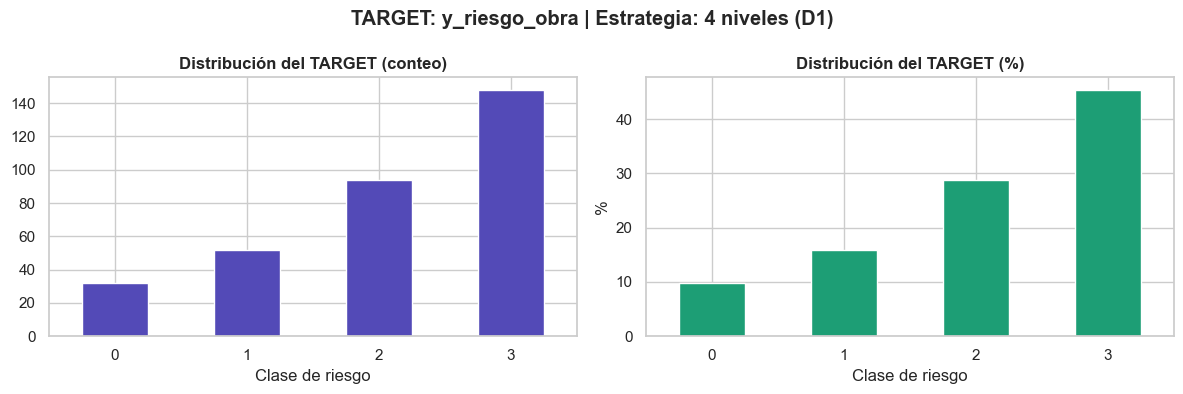

               cantidad     pct
y_riesgo_obra                  
0                    32  9.8000
1                    52 16.0000
2                    94 28.8000
3                   148 45.4000


In [112]:
# ============================================================
# 6.5 — DISTRIBUCIÓN FINAL DEL TARGET
# ============================================================

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Conteo
vc = dataset[TARGET_COL].value_counts().sort_index()
vc.plot(kind="bar", ax=axes[0], color="#534AB7", edgecolor="white")
axes[0].set_title("Distribución del TARGET (conteo)", fontweight="bold")
axes[0].set_xlabel("Clase de riesgo")
axes[0].tick_params(axis="x", rotation=0)

# Porcentaje
(vc / vc.sum() * 100).plot(kind="bar", ax=axes[1], color="#1D9E75", edgecolor="white")
axes[1].set_title("Distribución del TARGET (%)", fontweight="bold")
axes[1].set_xlabel("Clase de riesgo")
axes[1].tick_params(axis="x", rotation=0)
axes[1].set_ylabel("%")

plt.suptitle("TARGET: y_riesgo_obra | Estrategia: 4 niveles (D1)", fontweight="bold")
plt.tight_layout()
plt.show()

print(vc.to_frame("cantidad").assign(pct=(vc/vc.sum()*100).round(1)))


---
## PASO 7 — Preparar X / y y exportar

In [113]:
# ============================================================
# 7.1 — SEPARAR X e y
# ============================================================

TARGET_COL = "y_riesgo_obra"

cols_excluir_modelo = [
    "IDENTIFICADOR_OBRA",
    "RIESGO_OBRA",
    "RIESGO_DESCRIPCION_OBRA",
    TARGET_COL,
]

X = dataset.drop(columns=[c for c in cols_excluir_modelo if c in dataset.columns]).copy()
y = dataset[TARGET_COL].astype(int).copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nColumnas de X:")
for i, c in enumerate(X.columns, 1):
    print(f"  {i:02d}. {c}")


X shape: (326, 77)
y shape: (326,)

Columnas de X:
  01. ETAPA
  02. DIAS_PLAZO
  03. TOTAL_CONTROL_PREVIO
  04. TOTAL_CONTROL_SIMULTANEO
  05. TOTAL_CONTROL_POSTERIOR
  06. obra_ctx_sector
  07. obra_ctx_nivel_gobierno
  08. obra_ctx_objeto_proceso
  09. obra_ctx_metodo_contratacion
  10. obra_ctx_departamento
  11. obra_monto_contractual_sum
  12. obra_monto_referencial_sum
  13. obra_monto_ofertado_prom_mean
  14. obra_n_contratos_ganados
  15. obra_n_participantes_mean
  16. obra_n_participantes_max
  17. obra_ratio_contractual_referencial
  18. obra_ahorro_absoluto
  19. obra_sobre_referencial
  20. obra_ratio_oferta_contrato
  21. obra_n_miembros_comite
  22. obra_n_dnis_comite_unicos
  23. obra_n_convocatorias_comite
  24. obra_n_procesos_comite
  25. obra_ratio_repeticion_comite
  26. obra_comite_no_estandar
  27. obra_n_participaciones
  28. obra_n_rucs_participantes
  29. obra_n_contratos
  30. obra_n_procesos
  31. obra_n_contratos_postor_unico
  32. obra_n_contratos_total_p

In [114]:
# ============================================================
# 7.2 — EXPORTAR DATASET COMPLETO (con nulos)
# ============================================================

output_full = DATA_PROC / "dataset_obra_v4_model.parquet"

dataset_export = dataset.drop(columns=["RIESGO_OBRA", "RIESGO_DESCRIPCION_OBRA"], errors="ignore")

dataset_export.to_parquet(output_full, index=False)

print("✅ Dataset exportado:", output_full)
print("   Shape:", dataset_export.shape)


✅ Dataset exportado: C:\IA_Investigacion\Deteccion_Corrupcion\data\processed\dataset_obra_v4_model.parquet
   Shape: (326, 79)


In [115]:
# ============================================================
# 7.3 — RESUMEN FINAL
# ============================================================

print("=" * 70)
print("RESUMEN DATASET obra_v4")
print("=" * 70)
print(f"  Observaciones     : {len(dataset_export):>6,}")
print(f"  Features totales  : {len(X.columns):>6,}")
print(f"  Target strategy   : 4 niveles (Decisión D1)")
print(f"  Clases en target  : {sorted(y.unique())}")
print()
print("Distribución target:")
for k, v in y.value_counts().sort_index().items():
    print(f"  Clase {k}: {v:>3} obs ({v/len(y)*100:.1f}%)")
print()

# Nulos en X
pct_nulo_x = X.isna().mean()
print(f"Features sin nulos    : {(pct_nulo_x == 0).sum()}")
print(f"Features con <20% nul : {((pct_nulo_x > 0) & (pct_nulo_x < 0.2)).sum()}")
print(f"Features con >20% nul : {(pct_nulo_x >= 0.2).sum()}")
print()
print("✅ Listo para → 03_train_obra_v4.ipynb")


RESUMEN DATASET obra_v4
  Observaciones     :    326
  Features totales  :     77
  Target strategy   : 4 niveles (Decisión D1)
  Clases en target  : [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]

Distribución target:
  Clase 0:  32 obs (9.8%)
  Clase 1:  52 obs (16.0%)
  Clase 2:  94 obs (28.8%)
  Clase 3: 148 obs (45.4%)

Features sin nulos    : 41
Features con <20% nul : 36
Features con >20% nul : 0

✅ Listo para → 03_train_obra_v4.ipynb


In [116]:
print("\nDetalle features con >20% nulos:")
for col, pct in pct_nulo_x[pct_nulo_x >= 0.2].sort_values(ascending=False).items():
    print(f"  {col:45s}: {pct*100:.1f}%")


Detalle features con >20% nulos:
